# Tahoe Cross-Cell-Line Exploration

**Goal**: Understand the data landscape before running cross-cell-line training experiments.

Key questions:
1. How similar are cell lines transcriptomically? (PCA of pseudobulk control profiles)
2. How are drugs distributed in embedding space? (UMAP of 368 drug embeddings)
3. Are drug effects conserved across cell lines? (cross-cell effect correlation)
4. Does embedding distance predict effect similarity? (embedding ↔ effect correlation)

**Two distinct transfer mechanisms to test later**:
- **Cross-cell-line transfer (B1-C3)**: The model sees Drug X in A549, can it predict Drug X in SW48? This works through the embedding as an *identifier* — even with zero embedding structure.
- **Unseen drug generalization (A1-A2)**: The model hasn't seen Drug Y at all, can it predict its effect from nearby drugs in embedding space? This requires embedding structure.

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform, cosine
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert'

# Cell lines to load (all 7 available Tahoe cell lines)
CELLLINES = {
    'A549':   'tahoe_a549_w_emb.h5ad',
    'SW48':   'tahoe_sw48_w_emb.h5ad',
    'SNU-1':  'tahoe_snu_1_w_emb.h5ad',
    'H4':     'tahoe_h4_w_emb.h5ad',
    'ASPC-1': 'tahoe_aspc_1_w_emb.h5ad',
    'HOP62':  'tahoe_hop62_w_emb.h5ad',
    'PANC-1': 'tahoe_panc_1_w_emb.h5ad',
}

# Roles from Tahoe paper
TRAIN_CELLLINES = ['A549', 'SW48', 'SNU-1', 'H4', 'ASPC-1']
HOLDOUT_CELLLINES = ['HOP62', 'PANC-1']

/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 1. Dataset Census

Load all 7 cell lines (backed), confirm drug lists, cell counts, embedding dimensions.

In [2]:
# Load metadata only (backed) for census
census = {}
drug_sets = {}
control_embs = {}  # will store control cell X_state for later

for name, fname in CELLLINES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        # Try without _w_emb
        path = os.path.join(DATA_DIR, fname.replace('_w_emb', '_w_se').replace('_w_se', ''))
    
    print(f'\nLoading {name}: {path}')
    adata = ad.read_h5ad(path, backed='r')
    
    drugs = [d for d in adata.obs['drug_0'].unique() if d != 'control']
    drug_sets[name] = set(drugs)
    
    n_control = (adata.obs['drug_0'] == 'control').sum()
    
    # Check embedding keys
    uns_keys = list(adata.uns.keys()) if hasattr(adata, 'uns') else []
    obsm_keys = list(adata.obsm.keys()) if hasattr(adata, 'obsm') else []
    
    census[name] = {
        'n_cells': adata.n_obs,
        'n_drugs': len(drugs),
        'n_control': n_control,
        'cell_line_id': adata.obs['cell_line'].iloc[0] if 'cell_line' in adata.obs.columns else 'NA',
        'X_state_dim': adata.obsm['X_state'].shape[1] if 'X_state' in obsm_keys else 'NA',
        'has_drug_emb': 'drug_0_embeddings' in uns_keys,
    }
    
    print(f'  Cells: {census[name]["n_cells"]:,} | Drugs: {census[name]["n_drugs"]} | '
          f'Control: {n_control:,} | X_state: {census[name]["X_state_dim"]}d')

pd.DataFrame(census).T


Loading A549: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_emb.h5ad
  Cells: 2,326,890 | Drugs: 367 | Control: 57,448 | X_state: 2058d

Loading SW48: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_sw48_w_emb.h5ad
  Cells: 849,525 | Drugs: 367 | Control: 21,102 | X_state: 2058d

Loading SNU-1: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_snu_1_w_emb.h5ad
  Cells: 1,138,884 | Drugs: 367 | Control: 28,611 | X_state: 2058d

Loading H4: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_h4_w_emb.h5ad
  Cells: 952,254 | Drugs: 367 | Control: 23,311 | X_state: 2058d

Loading ASPC-1: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_aspc_1_w_emb.h5ad
  Cells: 2,026,821 | Drugs: 367 | Control: 48,933 | X_state: 2058d

Loading HOP62: /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_hop62_w_emb.h5ad
  Cells: 3,009,751 | Drugs: 367 | Control

,n_cells,n_drugs,n_control,cell_line_id,X_state_dim,has_drug_emb
A549,2326890,367,57448,CVCL_0023,2058,True
SW48,849525,367,21102,CVCL_1724,2058,True
SNU-1,1138884,367,28611,CVCL_0099,2058,True
H4,952254,367,23311,CVCL_1239,2058,True
ASPC-1,2026821,367,48933,CVCL_0152,2058,True
HOP62,3009751,367,72168,CVCL_1285,2058,True
PANC-1,3766070,367,91906,CVCL_0480,2058,True


Drug intersection across all 7 cell lines: 367 drugs
Drug union: 367 drugs


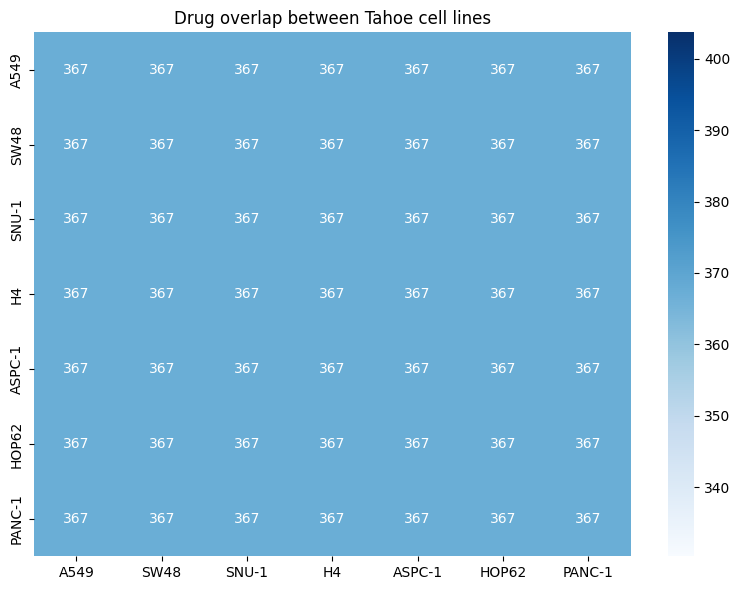

In [3]:
# Drug overlap across all cell lines
all_drugs = set.intersection(*drug_sets.values())
print(f'Drug intersection across all 7 cell lines: {len(all_drugs)} drugs')
print(f'Drug union: {len(set.union(*drug_sets.values()))} drugs')

# Pairwise overlap
cl_names = list(CELLLINES.keys())
overlap = pd.DataFrame(index=cl_names, columns=cl_names, dtype=int)
for i, c1 in enumerate(cl_names):
    for j, c2 in enumerate(cl_names):
        overlap.loc[c1, c2] = len(drug_sets[c1] & drug_sets[c2])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap.astype(int), annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Drug overlap between Tahoe cell lines')
plt.tight_layout()
plt.show()

## 2. Cell-Line Transcriptomic Similarity

PCA of pseudobulk control profiles to reproduce Tahoe Fig S3 and measure pairwise distances.

In [4]:
# Load control cell X_state embeddings for each cell line
# Subsample to 10K control cells per cell line for speed
MAX_CONTROL = 10000

pseudobulks = {}  # cell_line -> mean X_state of control cells
control_samples = {}  # cell_line -> (N, D) X_state for sampled control cells

for name, fname in CELLLINES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        path = os.path.join(DATA_DIR, fname.replace('_w_emb', '_w_se'))
    
    adata = ad.read_h5ad(path, backed='r')
    ctrl_idx = np.where(adata.obs['drug_0'].values == 'control')[0]
    
    if len(ctrl_idx) > MAX_CONTROL:
        rng = np.random.default_rng(42)
        ctrl_idx = rng.choice(ctrl_idx, MAX_CONTROL, replace=False)
    
    X_ctrl = adata.obsm['X_state'][ctrl_idx]
    pseudobulks[name] = np.mean(X_ctrl, axis=0)
    control_samples[name] = X_ctrl
    print(f'{name}: {len(ctrl_idx)} control cells loaded')

# PCA of pseudobulks
pb_matrix = np.stack([pseudobulks[c] for c in cl_names])
pca = PCA(n_components=min(7, len(cl_names)))
pb_pca = pca.fit_transform(pb_matrix)



A549: 10000 control cells loaded
SW48: 10000 control cells loaded
SNU-1: 10000 control cells loaded
H4: 10000 control cells loaded
ASPC-1: 10000 control cells loaded
HOP62: 10000 control cells loaded
PANC-1: 10000 control cells loaded


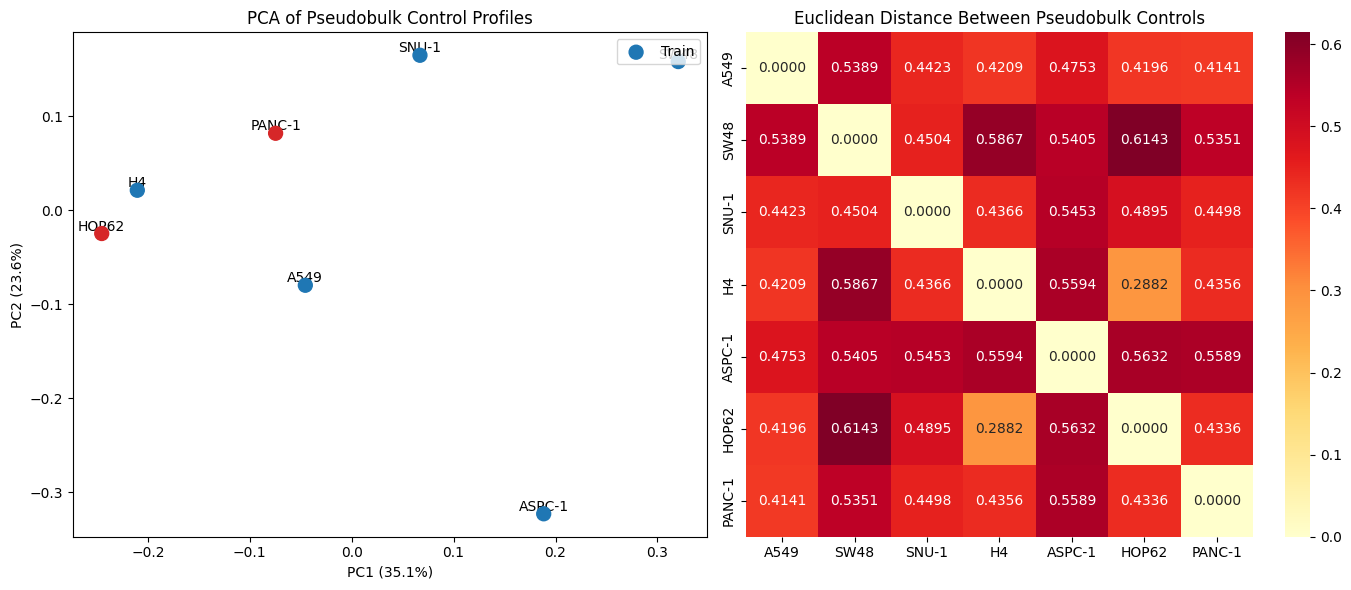


Pairwise distances (sorted by distance to A549):
  A549 ↔ A549: 0.0000
  A549 ↔ PANC-1: 0.4141
  A549 ↔ HOP62: 0.4196
  A549 ↔ H4: 0.4209
  A549 ↔ SNU-1: 0.4423
  A549 ↔ ASPC-1: 0.4753
  A549 ↔ SW48: 0.5389


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# PC1 vs PC2
ax = axes[0]
colors = ['#1f77b4' if c in TRAIN_CELLLINES else '#d62728' for c in cl_names]
ax.scatter(pb_pca[:, 0], pb_pca[:, 1], c=colors, s=100, zorder=5)
for i, name in enumerate(cl_names):
    ax.annotate(name, (pb_pca[i, 0], pb_pca[i, 1]), fontsize=10, ha='center', va='bottom')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA of Pseudobulk Control Profiles')
ax.legend(['Train', 'Holdout'], loc='upper right')

# Pairwise distance heatmap
ax = axes[1]
dist_matrix = squareform(pdist(pb_matrix, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, index=cl_names, columns=cl_names)
sns.heatmap(dist_df, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('Euclidean Distance Between Pseudobulk Controls')

plt.tight_layout()
plt.show()

print('\nPairwise distances (sorted by distance to A549):')
a549_idx = cl_names.index('A549')
for name in sorted(cl_names, key=lambda c: dist_matrix[a549_idx, cl_names.index(c)]):
    print(f'  A549 ↔ {name}: {dist_matrix[a549_idx, cl_names.index(name)]:.4f}')

## 3. Drug Embedding Space

UMAP of 368 drug embeddings. Identify structure/clusters.

Drug embeddings: 367 drugs × 256d


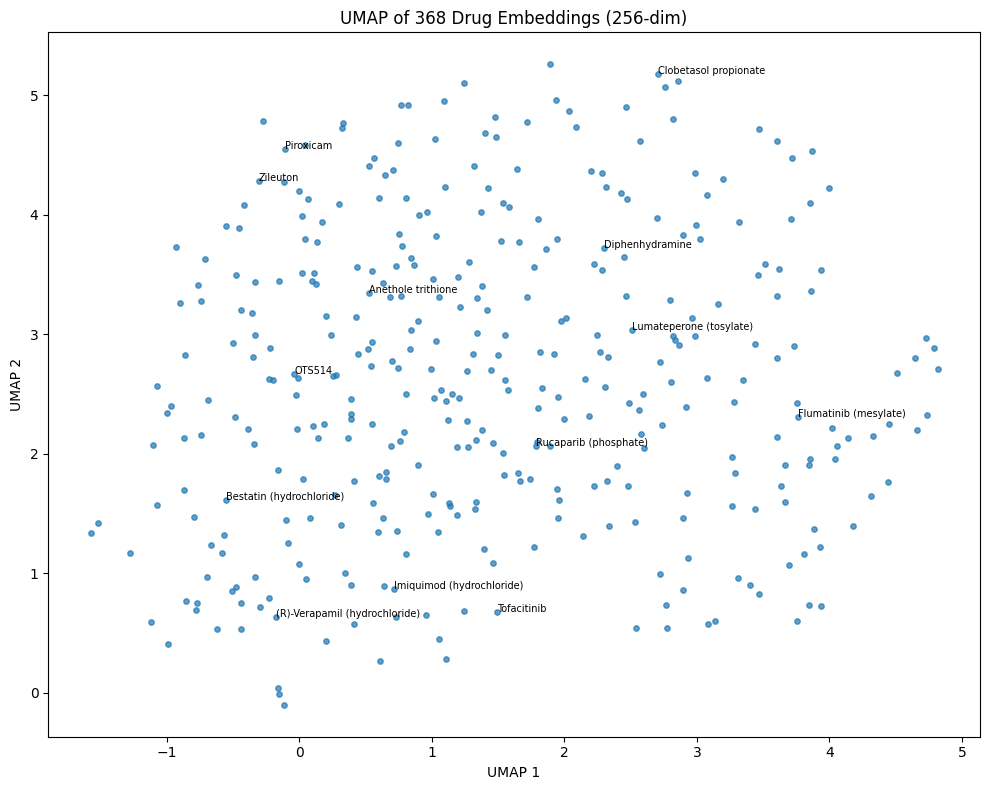

In [6]:
# Load drug embeddings from one cell line (they're identical across all)
adata = ad.read_h5ad(os.path.join(DATA_DIR, CELLLINES['A549']), backed='r')
drug_emb_dict = dict(adata.uns['drug_0_embeddings'])

drug_names = sorted([d for d in drug_emb_dict.keys() if d != 'control'])
drug_emb_matrix = np.stack([drug_emb_dict[d] for d in drug_names])

print(f'Drug embeddings: {drug_emb_matrix.shape[0]} drugs × {drug_emb_matrix.shape[1]}d')

# UMAP
from umap import UMAP
reducer = UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
drug_umap = reducer.fit_transform(drug_emb_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(drug_umap[:, 0], drug_umap[:, 1], s=15, alpha=0.7)
# Label a few drugs
for i, name in enumerate(drug_names):
    if i % 30 == 0:  # label every 30th drug
        ax.annotate(name, (drug_umap[i, 0], drug_umap[i, 1]), fontsize=7)
ax.set_title('UMAP of 368 Drug Embeddings (256-dim)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 4. Cross-Cell-Line Effect Correlation ★ KEY ANALYSIS

For each drug, compute mean expression shift in X_state space per cell line.
Then correlate drug effect vectors across cell lines.

If effects are highly correlated → drug effects are conserved, cross-cell adds little new info.
If effects are uncorrelated → drug effects are cell-specific, cross-cell might add new signal.

In [7]:
# For speed, use a subset of cell lines and subsample cells
EFFECT_CELLLINES = ['A549', 'SW48', 'PANC-1', 'HOP62']  # similar pair + dissimilar + moderate
MAX_CELLS_PER_DRUG = 200
N_PCS = 50  # number of PCA components for dimensionality reduction

# Step 1: Collect a sample of cells (control + perturbed) per cell line to fit PCA
# We fit ONE shared PCA across all cell lines so effect vectors are comparable
print('Sampling cells for PCA fitting...')
rng = np.random.default_rng(42)
pca_samples = []

raw_data = {}  # {cl_name: {drug: X_state array, 'control': X_state array}}

for cl_name in EFFECT_CELLLINES:
    path = os.path.join(DATA_DIR, CELLLINES[cl_name])
    adata = ad.read_h5ad(path, backed='r')
    cl_data = {}
    
    # Sample control cells
    ctrl_idx = np.where(adata.obs['drug_0'].values == 'control')[0]
    ctrl_sample = rng.choice(ctrl_idx, min(5000, len(ctrl_idx)), replace=False)
    ctrl_X = np.array(adata.obsm['X_state'][ctrl_sample])
    cl_data['control'] = ctrl_X
    pca_samples.append(ctrl_X)
    
    # Sample perturbed cells
    drugs_in_cl = [d for d in adata.obs['drug_0'].unique() if d != 'control']
    for drug in drugs_in_cl:
        drug_idx = np.where(adata.obs['drug_0'].values == drug)[0]
        if len(drug_idx) < 10:
            continue
        if len(drug_idx) > MAX_CELLS_PER_DRUG:
            drug_idx = rng.choice(drug_idx, MAX_CELLS_PER_DRUG, replace=False)
        drug_X = np.array(adata.obsm['X_state'][drug_idx])
        cl_data[drug] = drug_X
        pca_samples.append(drug_X)
    
    raw_data[cl_name] = cl_data
    print(f'  {cl_name}: sampled control + {len(cl_data) - 1} drugs')

# Step 2: Fit shared PCA on all sampled cells
print(f'\nFitting PCA ({N_PCS} components) on all sampled cells...')
all_cells = np.concatenate(pca_samples, axis=0)
print(f'  Total cells for PCA: {all_cells.shape[0]:,} x {all_cells.shape[1]}d')
pca_effect = PCA(n_components=N_PCS, random_state=42)
pca_effect.fit(all_cells)
print(f'  Explained variance: {pca_effect.explained_variance_ratio_.sum():.1%} in {N_PCS} PCs')
del all_cells, pca_samples  # free memory

# Step 3: Compute per-drug mean shift in PCA space
print('\nComputing drug effects in PCA space...')
drug_effects = {}  # {cell_line: {drug: mean_shift_vector in PCA space}}

for cl_name in EFFECT_CELLLINES:
    ctrl_pca = pca_effect.transform(raw_data[cl_name]['control'])
    ctrl_mean = np.mean(ctrl_pca, axis=0)
    
    effects = {}
    for drug, drug_X in raw_data[cl_name].items():
        if drug == 'control':
            continue
        drug_pca = pca_effect.transform(drug_X)
        drug_mean = np.mean(drug_pca, axis=0)
        effects[drug] = drug_mean - ctrl_mean
    
    drug_effects[cl_name] = effects
    print(f'  {cl_name}: {len(effects)} drug effects computed')

del raw_data  # free memory

# Find common drugs
common_drugs = sorted(set.intersection(*[set(v.keys()) for v in drug_effects.values()]))
print(f'\nCommon drugs across {len(EFFECT_CELLLINES)} cell lines: {len(common_drugs)}')

Sampling cells for PCA fitting...
  A549: sampled control + 367 drugs
  SW48: sampled control + 367 drugs
  PANC-1: sampled control + 367 drugs
  HOP62: sampled control + 367 drugs

Fitting PCA (50 components) on all sampled cells...
  Total cells for PCA: 313,600 x 2058d
  Explained variance: 21.4% in 50 PCs

Computing drug effects in PCA space...
  A549: 367 drug effects computed
  SW48: 367 drug effects computed
  PANC-1: 367 drug effects computed
  HOP62: 367 drug effects computed

Common drugs across 4 cell lines: 367


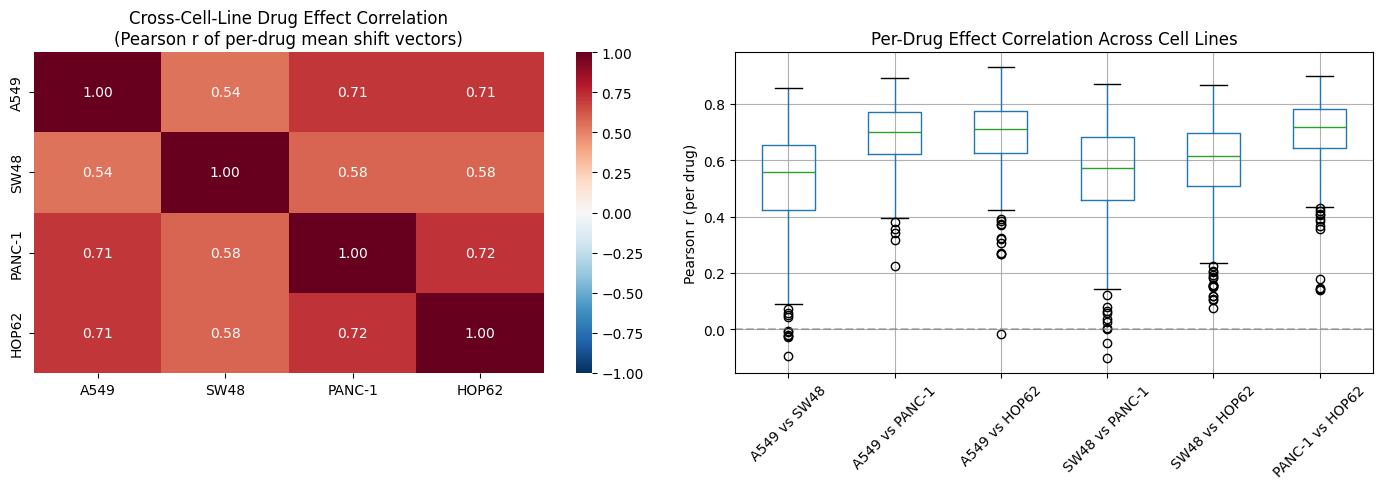


Median per-drug correlation:
  A549 vs SW48: 0.560 (mean=0.524)
  A549 vs PANC-1: 0.699 (mean=0.686)
  A549 vs HOP62: 0.710 (mean=0.689)
  SW48 vs PANC-1: 0.572 (mean=0.550)
  SW48 vs HOP62: 0.613 (mean=0.579)
  PANC-1 vs HOP62: 0.719 (mean=0.700)


In [8]:
# Cross-cell-line effect correlation
# For each pair of cell lines, correlate their per-drug effect vectors

n_cl = len(EFFECT_CELLLINES)
corr_matrix = np.zeros((n_cl, n_cl))

for i, cl1 in enumerate(EFFECT_CELLLINES):
    for j, cl2 in enumerate(EFFECT_CELLLINES):
        # Stack effect vectors for common drugs
        v1 = np.stack([drug_effects[cl1][d] for d in common_drugs]).flatten()
        v2 = np.stack([drug_effects[cl2][d] for d in common_drugs]).flatten()
        corr_matrix[i, j] = pearsonr(v1, v2)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of correlations
ax = axes[0]
sns.heatmap(pd.DataFrame(corr_matrix, index=EFFECT_CELLLINES, columns=EFFECT_CELLLINES),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Cross-Cell-Line Drug Effect Correlation\n(Pearson r of per-drug mean shift vectors)')

# Per-drug correlation (not flattened)
ax = axes[1]
per_drug_corrs = {}
for i, cl1 in enumerate(EFFECT_CELLLINES):
    for j, cl2 in enumerate(EFFECT_CELLLINES):
        if i >= j:
            continue
        corrs = []
        for drug in common_drugs:
            r, _ = pearsonr(drug_effects[cl1][drug], drug_effects[cl2][drug])
            corrs.append(r)
        per_drug_corrs[f'{cl1} vs {cl2}'] = corrs

per_drug_df = pd.DataFrame(per_drug_corrs)
per_drug_df.boxplot(ax=ax, rot=45)
ax.set_ylabel('Pearson r (per drug)')
ax.set_title('Per-Drug Effect Correlation Across Cell Lines')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('\nMedian per-drug correlation:')
for pair, corrs in per_drug_corrs.items():
    print(f'  {pair}: {np.median(corrs):.3f} (mean={np.mean(corrs):.3f})')

## 5. Embedding ↔ Effect Correlation

Does drug embedding distance predict effect similarity?

**What this tells us**: Whether the embedding space supports generalization to **completely unseen drugs** (drugs not in training at all). If nearby drugs have similar effects, the model can interpolate.

**What this does NOT tell us about**: Cross-cell-line transfer of **seen drugs**. Even if the embedding space has zero structure, the model can still memorize "embedding X → effect Y" in A549 and transfer that mapping to SW48. The embedding acts as an identifier, not a similarity metric. Cross-cell-line transfer (experiments B1-C3) tests this — and it works independently of embedding quality.

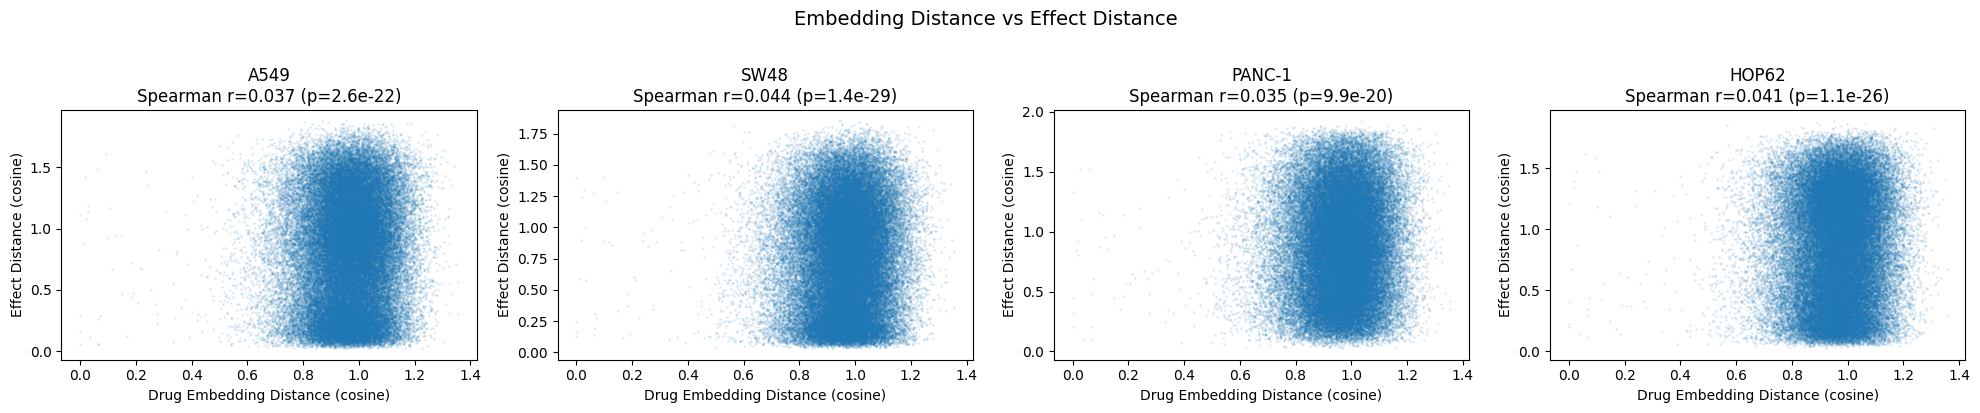

In [9]:
# Compute pairwise drug embedding distances
common_drug_embs = np.stack([drug_emb_dict[d] for d in common_drugs])
emb_dists = squareform(pdist(common_drug_embs, metric='cosine'))  # cosine distance

# For each cell line, compute pairwise effect distances
fig, axes = plt.subplots(1, len(EFFECT_CELLLINES), figsize=(5*len(EFFECT_CELLLINES), 4))

for idx, cl_name in enumerate(EFFECT_CELLLINES):
    ax = axes[idx]
    effect_matrix = np.stack([drug_effects[cl_name][d] for d in common_drugs])
    effect_dists = squareform(pdist(effect_matrix, metric='cosine'))
    
    # Flatten upper triangle
    triu_idx = np.triu_indices(len(common_drugs), k=1)
    emb_flat = emb_dists[triu_idx]
    eff_flat = effect_dists[triu_idx]
    
    # Remove NaN
    valid = ~(np.isnan(emb_flat) | np.isnan(eff_flat))
    emb_flat = emb_flat[valid]
    eff_flat = eff_flat[valid]
    
    r, p = spearmanr(emb_flat, eff_flat)
    
    ax.scatter(emb_flat, eff_flat, s=1, alpha=0.1)
    ax.set_xlabel('Drug Embedding Distance (cosine)')
    ax.set_ylabel('Effect Distance (cosine)')
    ax.set_title(f'{cl_name}\nSpearman r={r:.3f} (p={p:.1e})')

plt.suptitle('Embedding Distance vs Effect Distance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Drug Effect Magnitude Distribution

Which drugs have the strongest effects? Are strong-effect drugs consistent across cell lines?

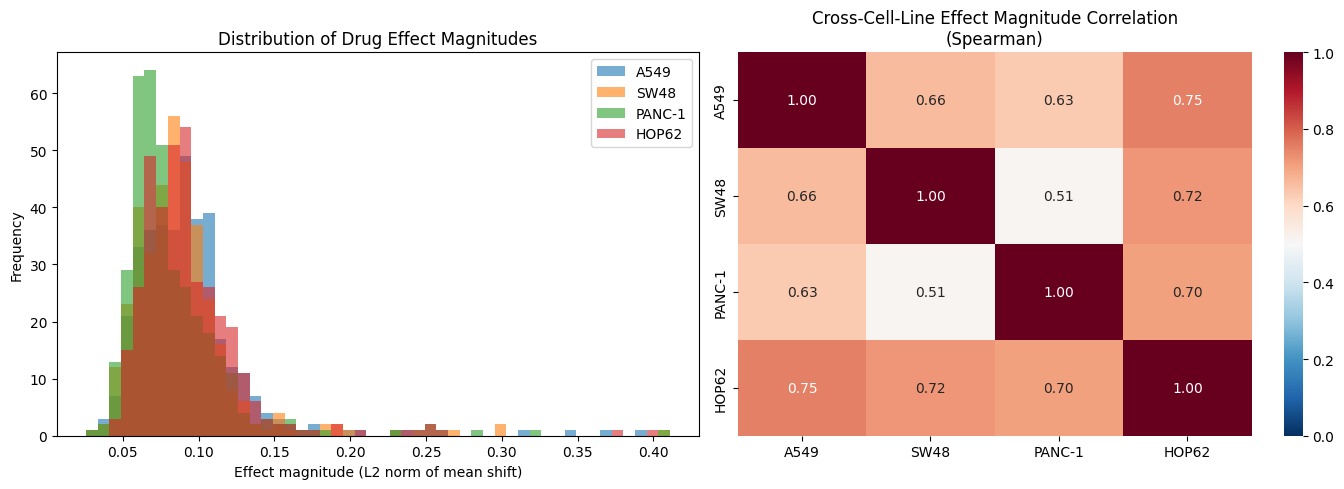


Top 10 strongest-effect drugs per cell line:

A549: ['Dinaciclib', 'Panobinostat', 'Harringtonine', 'Homoharringtonine', 'Belinostat', 'Ouabain (Octahydrate)', 'Digitoxin', 'TAK-901', 'Ixazomib citrate', 'c-Kit-IN-1']

SW48: ['Dinaciclib', 'Panobinostat', 'Homoharringtonine', 'Harringtonine', 'TAK-901', 'Digitoxin', 'Bortezomib', 'Idarubicin (hydrochloride)', 'Ouabain (Octahydrate)', 'Belinostat']

PANC-1: ['Dinaciclib', 'Panobinostat', 'Harringtonine', 'TAK-901', 'Ouabain (Octahydrate)', 'Homoharringtonine', 'Digitoxin', 'Belinostat', 'c-Kit-IN-1', 'Pentagastrin']

HOP62: ['Dinaciclib', 'Panobinostat', 'Digitoxin', 'Harringtonine', 'Ouabain (Octahydrate)', 'Belinostat', 'Homoharringtonine', 'Ixazomib citrate', 'Bortezomib', 'Brivudine']


In [10]:
# Effect magnitude per drug per cell line
effect_magnitudes = {}
for cl_name in EFFECT_CELLLINES:
    mags = {drug: np.linalg.norm(drug_effects[cl_name][drug]) for drug in common_drugs}
    effect_magnitudes[cl_name] = mags

mag_df = pd.DataFrame(effect_magnitudes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of effect magnitudes
ax = axes[0]
mag_df.plot.hist(bins=50, alpha=0.6, ax=ax)
ax.set_xlabel('Effect magnitude (L2 norm of mean shift)')
ax.set_title('Distribution of Drug Effect Magnitudes')

# Correlation of effect magnitudes across cell lines
ax = axes[1]
mag_corr = mag_df.corr(method='spearman')
sns.heatmap(mag_corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1, ax=ax)
ax.set_title('Cross-Cell-Line Effect Magnitude Correlation\n(Spearman)')

plt.tight_layout()
plt.show()

# Top 10 strongest drugs per cell line
print('\nTop 10 strongest-effect drugs per cell line:')
for cl_name in EFFECT_CELLLINES:
    top = mag_df[cl_name].nlargest(10)
    print(f'\n{cl_name}: {list(top.index)}')

## 7. Cell-Line Distance vs Effect Correlation

Does transcriptomic similarity between cell lines predict how conserved drug effects are?
If yes → similar cell lines should benefit more from cross-cell-line transfer.
If no → cell-line distance is not a good predictor of transfer potential.

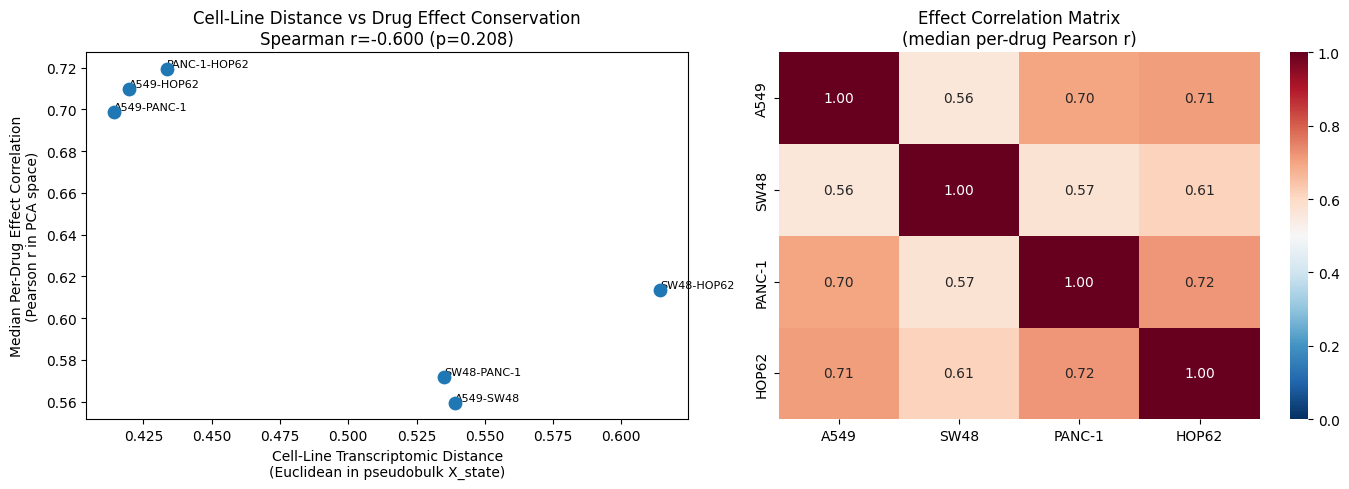


Spearman correlation between cell-line distance and effect correlation: r=-0.600 (p=0.208)

Interpretation:
  → More distant cell lines have LESS correlated drug effects.
  → Cross-cell-line transfer should work better for similar cell lines.

Pair details (sorted by transcriptomic distance):
    A549 ↔ PANC-1: dist=0.4141, effect_corr=0.699
    A549 ↔ HOP62 : dist=0.4196, effect_corr=0.710
  PANC-1 ↔ HOP62 : dist=0.4336, effect_corr=0.719
    SW48 ↔ PANC-1: dist=0.5351, effect_corr=0.572
    A549 ↔ SW48  : dist=0.5389, effect_corr=0.560
    SW48 ↔ HOP62 : dist=0.6143, effect_corr=0.613


In [11]:
# Compute pairwise cell-line distances (from pseudobulk controls, Section 2)
# and pairwise effect correlations (from Section 4)
# Then scatter-plot one against the other.

pairs_data = []
for i, cl1 in enumerate(EFFECT_CELLLINES):
    for j, cl2 in enumerate(EFFECT_CELLLINES):
        if i >= j:
            continue
        # Cell-line transcriptomic distance (Euclidean in X_state pseudobulk space)
        idx1 = cl_names.index(cl1)
        idx2 = cl_names.index(cl2)
        cl_dist = dist_matrix[idx1, idx2]
        
        # Median per-drug effect correlation
        pair_key = f'{cl1} vs {cl2}'
        if pair_key in per_drug_corrs:
            med_corr = np.median(per_drug_corrs[pair_key])
            mean_corr = np.mean(per_drug_corrs[pair_key])
        else:
            # Try reverse order
            pair_key = f'{cl2} vs {cl1}'
            med_corr = np.median(per_drug_corrs[pair_key])
            mean_corr = np.mean(per_drug_corrs[pair_key])
        
        pairs_data.append({
            'Cell Line 1': cl1,
            'Cell Line 2': cl2,
            'Transcriptomic Distance': cl_dist,
            'Median Effect Corr': med_corr,
            'Mean Effect Corr': mean_corr,
        })

pairs_df = pd.DataFrame(pairs_data)

# Correlation between the two
r_med, p_med = spearmanr(pairs_df['Transcriptomic Distance'], pairs_df['Median Effect Corr'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: cell-line distance vs effect correlation
ax = axes[0]
ax.scatter(pairs_df['Transcriptomic Distance'], pairs_df['Median Effect Corr'], s=80, zorder=5)
for _, row in pairs_df.iterrows():
    label = f"{row['Cell Line 1']}-{row['Cell Line 2']}"
    ax.annotate(label, (row['Transcriptomic Distance'], row['Median Effect Corr']),
                fontsize=8, ha='left', va='bottom')
ax.set_xlabel('Cell-Line Transcriptomic Distance\n(Euclidean in pseudobulk X_state)')
ax.set_ylabel('Median Per-Drug Effect Correlation\n(Pearson r in PCA space)')
ax.set_title(f'Cell-Line Distance vs Drug Effect Conservation\nSpearman r={r_med:.3f} (p={p_med:.3f})')

# Heatmap side by side: distance matrix vs effect correlation matrix
ax = axes[1]
# Build effect correlation matrix for EFFECT_CELLLINES
n = len(EFFECT_CELLLINES)
eff_corr_mat = np.eye(n)
for _, row in pairs_df.iterrows():
    i = EFFECT_CELLLINES.index(row['Cell Line 1'])
    j = EFFECT_CELLLINES.index(row['Cell Line 2'])
    eff_corr_mat[i, j] = row['Median Effect Corr']
    eff_corr_mat[j, i] = row['Median Effect Corr']

# Subset distance matrix to EFFECT_CELLLINES
eff_dist_mat = np.zeros((n, n))
for i, cl1 in enumerate(EFFECT_CELLLINES):
    for j, cl2 in enumerate(EFFECT_CELLLINES):
        eff_dist_mat[i, j] = dist_matrix[cl_names.index(cl1), cl_names.index(cl2)]

# Plot as two triangles of the same heatmap
combined = np.triu(eff_corr_mat, k=0) + np.tril(eff_dist_mat, k=-1)
mask_upper = np.triu(np.ones_like(combined, dtype=bool), k=1)
mask_lower = np.tril(np.ones_like(combined, dtype=bool), k=-1)

sns.heatmap(pd.DataFrame(eff_corr_mat, index=EFFECT_CELLLINES, columns=EFFECT_CELLLINES),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1, ax=ax)
ax.set_title('Effect Correlation Matrix\n(median per-drug Pearson r)')

plt.tight_layout()
plt.show()

print(f'\nSpearman correlation between cell-line distance and effect correlation: '
      f'r={r_med:.3f} (p={p_med:.3f})')
print(f'\nInterpretation:')
if r_med < -0.3:
    print('  → More distant cell lines have LESS correlated drug effects.')
    print('  → Cross-cell-line transfer should work better for similar cell lines.')
elif r_med > 0.3:
    print('  → More distant cell lines have MORE correlated drug effects (unexpected).')
    print('  → Cell-line distance may not predict transfer difficulty.')
else:
    print('  → Weak/no relationship between cell-line distance and effect conservation.')
    print('  → Transfer difficulty is not simply determined by transcriptomic similarity.')

print(f'\nPair details (sorted by transcriptomic distance):')
for _, row in pairs_df.sort_values('Transcriptomic Distance').iterrows():
    print(f"  {row['Cell Line 1']:>6} ↔ {row['Cell Line 2']:<6}: "
          f"dist={row['Transcriptomic Distance']:.4f}, effect_corr={row['Median Effect Corr']:.3f}")

## 7b. CCLE Embedding Distance vs X_state Distance vs Effect Correlation

Section 7 used pseudobulk X_state distances. But the model now receives **CCLE 300-dim PCA**
embeddings as cell-line representations. Do the CCLE distances agree with the X_state distances?
And more importantly, do CCLE distances predict effect conservation?

This validates whether the CCLE embeddings we're feeding the model encode biologically meaningful
cell-line similarity.

CCLE embeddings loaded for 7/7 cell lines
  A549: dim=300
  SW48: dim=300
  SNU-1: dim=300
  H4: dim=300
  ASPC-1: dim=300
  HOP62: dim=300
  PANC-1: dim=300


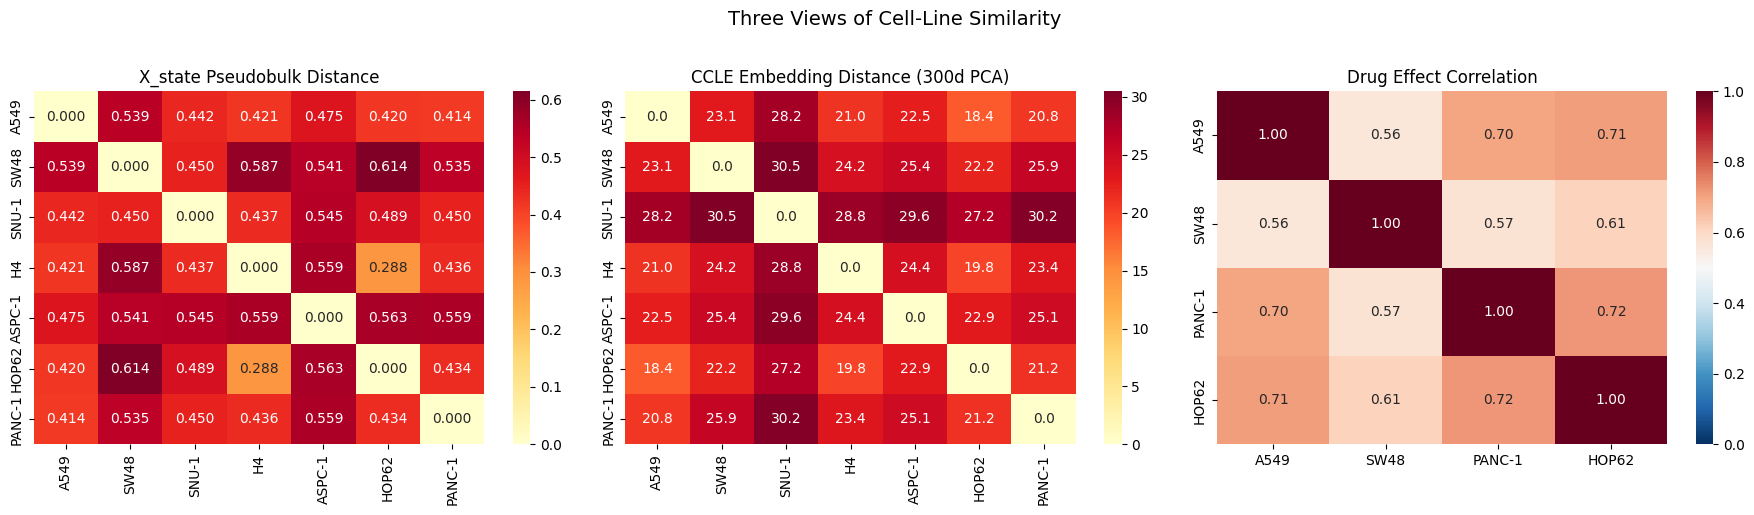

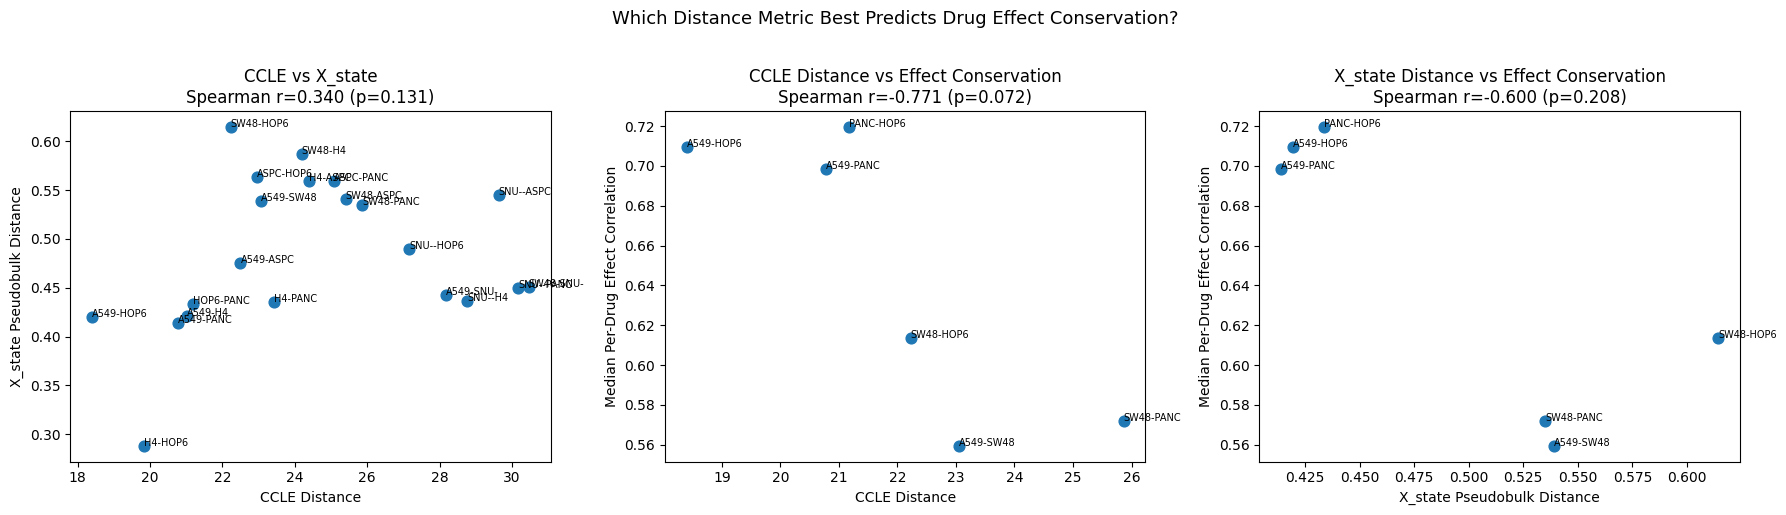


Correlation summary:
  CCLE dist vs X_state dist:       r=0.340 (p=0.131)
  CCLE dist vs effect corr:        r=-0.771 (p=0.072)
  X_state dist vs effect corr:     r=-0.600 (p=0.208)

Interpretation:
  CCLE and X_state distances DISAGREE — they capture different aspects of cell-line biology.


In [12]:
# Load CCLE embeddings for our 7 Tahoe cell lines
CCLE_PATH = '/lustre/groups/ml01/projects/super_rad_project/cell_line_embeddings/cell_line_embedding_full_ccle_300_scaled.csv'
ccle_df = pd.read_csv(CCLE_PATH, index_col=0)

def norm_name(name):
    return str(name).lower().replace('-', '').replace(' ', '').replace('_', '')

ccle_norm = {norm_name(n): n for n in ccle_df.index}

# Map Tahoe CVCL IDs -> CCLE names
CVCL_TO_COMMON = {
    'CVCL_0023': 'A549', 'CVCL_1724': 'SW48', 'CVCL_0099': 'SNU-1',
    'CVCL_1239': 'H4', 'CVCL_0152': 'AsPC-1', 'CVCL_1285': 'HOP-62',
    'CVCL_0480': 'PANC-1',
}

# Get CCLE embedding for each of our cell lines (use display names from cl_names)
ccle_embs = {}
for cl in cl_names:  # cl_names from Section 1
    norm = norm_name(cl)
    if norm in ccle_norm:
        ccle_embs[cl] = ccle_df.loc[ccle_norm[norm]].values
    else:
        # Try CVCL mapping (for Tahoe cell lines stored as CVCL IDs)
        for cvcl, common in CVCL_TO_COMMON.items():
            if norm_name(common) == norm or cvcl == cl:
                ccle_name = ccle_norm.get(norm_name(common))
                if ccle_name:
                    ccle_embs[cl] = ccle_df.loc[ccle_name].values
                    break

print(f'CCLE embeddings loaded for {len(ccle_embs)}/{len(cl_names)} cell lines')
for cl in cl_names:
    status = f'dim={ccle_embs[cl].shape[0]}' if cl in ccle_embs else 'MISSING'
    print(f'  {cl}: {status}')

# Compute CCLE pairwise distances
ccle_cls = [cl for cl in cl_names if cl in ccle_embs]
ccle_matrix = np.stack([ccle_embs[cl] for cl in ccle_cls])
ccle_dist_matrix = squareform(pdist(ccle_matrix, metric='euclidean'))
ccle_dist_df = pd.DataFrame(ccle_dist_matrix, index=ccle_cls, columns=ccle_cls)

# Compare three distance matrices: X_state pseudobulk, CCLE, and effect correlation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X_state distances (from Section 2)
ax = axes[0]
xstate_sub = dist_df.loc[ccle_cls, ccle_cls]
sns.heatmap(xstate_sub, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('X_state Pseudobulk Distance')

# CCLE distances
ax = axes[1]
sns.heatmap(ccle_dist_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('CCLE Embedding Distance (300d PCA)')

# Effect correlation (from Section 4, only for EFFECT_CELLLINES)
ax = axes[2]
eff_cls = [cl for cl in EFFECT_CELLLINES if cl in ccle_cls]
n = len(eff_cls)
eff_mat = np.eye(n)
for pair, corrs in per_drug_corrs.items():
    cl1, cl2 = pair.split(' vs ')
    if cl1 in eff_cls and cl2 in eff_cls:
        i, j = eff_cls.index(cl1), eff_cls.index(cl2)
        eff_mat[i, j] = np.median(corrs)
        eff_mat[j, i] = np.median(corrs)
sns.heatmap(pd.DataFrame(eff_mat, index=eff_cls, columns=eff_cls),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1, ax=ax)
ax.set_title('Drug Effect Correlation')

plt.suptitle('Three Views of Cell-Line Similarity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Scatter: CCLE distance vs X_state distance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CCLE vs X_state
ax = axes[0]
triu = np.triu_indices(len(ccle_cls), k=1)
ccle_flat = ccle_dist_matrix[triu]
xstate_flat = np.array(xstate_sub)[triu]
r_cx, p_cx = spearmanr(ccle_flat, xstate_flat)
ax.scatter(ccle_flat, xstate_flat, s=60)
for idx in range(len(triu[0])):
    i, j = triu[0][idx], triu[1][idx]
    ax.annotate(f'{ccle_cls[i][:4]}-{ccle_cls[j][:4]}',
                (ccle_flat[idx], xstate_flat[idx]), fontsize=7)
ax.set_xlabel('CCLE Distance')
ax.set_ylabel('X_state Pseudobulk Distance')
ax.set_title(f'CCLE vs X_state\nSpearman r={r_cx:.3f} (p={p_cx:.3f})')

# CCLE vs Effect correlation (only for EFFECT_CELLLINES)
ax = axes[1]
ccle_eff_pairs = []
eff_corr_pairs = []
labels = []
for pair, corrs in per_drug_corrs.items():
    cl1, cl2 = pair.split(' vs ')
    if cl1 in ccle_cls and cl2 in ccle_cls:
        i1, i2 = ccle_cls.index(cl1), ccle_cls.index(cl2)
        ccle_eff_pairs.append(ccle_dist_matrix[i1, i2])
        eff_corr_pairs.append(np.median(corrs))
        labels.append(f'{cl1[:4]}-{cl2[:4]}')

r_ce, p_ce = spearmanr(ccle_eff_pairs, eff_corr_pairs)
ax.scatter(ccle_eff_pairs, eff_corr_pairs, s=60)
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (ccle_eff_pairs[i], eff_corr_pairs[i]), fontsize=7)
ax.set_xlabel('CCLE Distance')
ax.set_ylabel('Median Per-Drug Effect Correlation')
ax.set_title(f'CCLE Distance vs Effect Conservation\nSpearman r={r_ce:.3f} (p={p_ce:.3f})')

# X_state vs Effect correlation
ax = axes[2]
xstate_eff_pairs = []
for pair, corrs in per_drug_corrs.items():
    cl1, cl2 = pair.split(' vs ')
    if cl1 in ccle_cls and cl2 in ccle_cls:
        xstate_eff_pairs.append(float(xstate_sub.loc[cl1, cl2]))

r_xe, p_xe = spearmanr(xstate_eff_pairs, eff_corr_pairs)
ax.scatter(xstate_eff_pairs, eff_corr_pairs, s=60)
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (xstate_eff_pairs[i], eff_corr_pairs[i]), fontsize=7)
ax.set_xlabel('X_state Pseudobulk Distance')
ax.set_ylabel('Median Per-Drug Effect Correlation')
ax.set_title(f'X_state Distance vs Effect Conservation\nSpearman r={r_xe:.3f} (p={p_xe:.3f})')

plt.suptitle('Which Distance Metric Best Predicts Drug Effect Conservation?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nCorrelation summary:')
print(f'  CCLE dist vs X_state dist:       r={r_cx:.3f} (p={p_cx:.3f})')
print(f'  CCLE dist vs effect corr:        r={r_ce:.3f} (p={p_ce:.3f})')
print(f'  X_state dist vs effect corr:     r={r_xe:.3f} (p={p_xe:.3f})')
print(f'\nInterpretation:')
if abs(r_cx) > 0.5:
    print('  CCLE and X_state distances are consistent — both capture similar cell-line structure.')
else:
    print('  CCLE and X_state distances DISAGREE — they capture different aspects of cell-line biology.')

## 8. Bulk Phenotype ↔ Single-Cell Effect: Does IC50 Predict Transcriptomic Shift?

Prophet's bulk datasets (GDSC, PRISM, CTRP) contain scalar phenotypes (IC50, viability) for 
thousands of (cell_line, drug) pairs. Tahoe provides single-cell transcriptomic responses for
the same drugs in the same cell lines (at least for overlapping pairs).

**Core question**: For a (cell_line, drug) pair, does the bulk IC50/viability value predict the
magnitude of the single-cell transcriptomic shift?

If yes → bulk phenotypic data carries information about single-cell-level effects. This would 
be the strongest motivation for integrating Prophet embeddings into CellFlow later.

**No Prophet model needed** — we just use the raw scalar values from the bulk h5ad files.

In [ ]:
# Step 1: Load bulk phenotype data from Prophet datasets
PROPHET_DIR = '/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/prophet'

bulk_data = {}  # {dataset_name: DataFrame with cell_line, drug, value}
for ds_name in ['GDSC', 'PRISM', 'CTRP']:
    path = f'{PROPHET_DIR}/{ds_name}.h5ad'
    adata_bulk = ad.read_h5ad(path)
    df = adata_bulk.obs[['cell_line', 'pert_compound']].copy()
    df['value'] = np.array(adata_bulk.X).flatten()
    df['drug'] = df['pert_compound'].str.lower().str.strip()
    df['cell_line_lower'] = df['cell_line'].str.lower().str.strip()
    bulk_data[ds_name] = df
    print(f'{ds_name}: {len(df):,} obs, {df["cell_line"].nunique()} cell lines, {df["drug"].nunique()} drugs')

print(f'\nBulk datasets loaded.')

In [ ]:
# Step 2: Map Tahoe cell line CVCL IDs to common names used in Prophet
# Manual mapping for our 7 Tahoe cell lines
CVCL_TO_NAME = {
    'CVCL_0023': 'A549',
    'CVCL_1724': 'SW48',
    'CVCL_0099': 'SNU-1',
    'CVCL_1239': 'H4',
    'CVCL_0152': 'AsPC-1',  # Note: Prophet may use 'ASPC1', 'AsPC-1', 'ASPC-1', etc.
    'CVCL_1285': 'HOP-62',  # Prophet may use 'HOP62', 'HOP-62', etc.
    'CVCL_0480': 'PANC-1',
}

# Step 3: Find drug name overlap between Tahoe and Prophet
# Tahoe drugs (from our loaded data)
tahoe_drugs_raw = sorted(all_drugs)  # from Section 1
tahoe_drugs_lower = {d.lower().strip(): d for d in tahoe_drugs_raw}

# Prophet drugs (union across all datasets)
prophet_drugs_lower = set()
for ds_name, df in bulk_data.items():
    prophet_drugs_lower.update(df['drug'].unique())

# Exact match (case-insensitive)
drug_overlap = set(tahoe_drugs_lower.keys()) & prophet_drugs_lower
print(f'Drug overlap (case-insensitive exact match):')
print(f'  Tahoe drugs: {len(tahoe_drugs_lower)}')
print(f'  Prophet drugs (union): {len(prophet_drugs_lower)}')
print(f'  Overlap: {len(drug_overlap)} ({len(drug_overlap)/len(tahoe_drugs_lower)*100:.0f}% of Tahoe)')

# Per-dataset overlap
for ds_name, df in bulk_data.items():
    ds_drugs = set(df['drug'].unique())
    ov = set(tahoe_drugs_lower.keys()) & ds_drugs
    print(f'  {ds_name}: {len(ov)} drugs overlap with Tahoe')

# Show some examples of overlapping drugs
print(f'\nSample overlapping drugs: {sorted(list(drug_overlap))[:20]}')

In [ ]:
# Step 4: For overlapping (cell_line, drug) pairs, compare bulk IC50 vs single-cell effect magnitude
# We already have drug_effects from Section 4 (per-drug mean shift in PCA space)

# Build (cell_line, drug) -> single-cell effect magnitude
sc_effect_magnitudes = {}
for cl_name in EFFECT_CELLLINES:
    for drug, effect_vec in drug_effects[cl_name].items():
        sc_effect_magnitudes[(cl_name, drug)] = np.linalg.norm(effect_vec)

# Match bulk values to single-cell effects
# For each bulk dataset, find overlapping (cell_line, drug) pairs
results_all = []

for ds_name, df in bulk_data.items():
    for cl_cvcl, cl_common in CVCL_TO_NAME.items():
        if cl_common not in [c for c in EFFECT_CELLLINES]:
            continue
        
        # Find this cell line in the bulk data (try multiple name variants)
        cl_variants = [cl_common, cl_common.lower(), cl_common.upper(), 
                       cl_common.replace('-', ''), cl_common.replace('-', ' ')]
        cl_mask = df['cell_line_lower'].isin([v.lower() for v in cl_variants])
        df_cl = df[cl_mask]
        
        if len(df_cl) == 0:
            continue
        
        for drug_lower in drug_overlap:
            drug_mask = df_cl['drug'] == drug_lower
            if drug_mask.sum() == 0:
                continue
            
            bulk_value = df_cl[drug_mask]['value'].mean()
            
            # Find matching Tahoe drug name
            tahoe_drug_name = tahoe_drugs_lower.get(drug_lower)
            if tahoe_drug_name is None:
                continue
            
            sc_mag = sc_effect_magnitudes.get((cl_common, tahoe_drug_name))
            if sc_mag is None:
                # Try the EFFECT_CELLLINES name mapping
                for ecl in EFFECT_CELLLINES:
                    if ecl.lower().replace('-','') == cl_common.lower().replace('-',''):
                        sc_mag = sc_effect_magnitudes.get((ecl, tahoe_drug_name))
                        break
            
            if sc_mag is not None:
                results_all.append({
                    'dataset': ds_name,
                    'cell_line': cl_common,
                    'drug': tahoe_drug_name,
                    'bulk_value': bulk_value,  # IC50/viability (0-1 normalized)
                    'sc_effect_magnitude': sc_mag,
                })

results_df = pd.DataFrame(results_all)
print(f'Matched (cell_line, drug) pairs with both bulk and single-cell data:')
print(f'  Total pairs: {len(results_df)}')
for ds_name in results_df['dataset'].unique():
    n = (results_df['dataset'] == ds_name).sum()
    n_cl = results_df[results_df['dataset'] == ds_name]['cell_line'].nunique()
    print(f'  {ds_name}: {n} pairs across {n_cl} cell lines')

results_df.head(10)

In [ ]:
# Step 5: Visualize and correlate bulk phenotype vs single-cell effect
# Note: For GDSC/CTRP, lower bulk_value = lower IC50 = more potent = expected larger SC effect
# For PRISM, lower bulk_value = more cell death = more potent

if len(results_df) == 0:
    print('WARNING: No overlapping (cell_line, drug) pairs found.')
    print('This likely means cell line name mapping needs refinement.')
    print('\nDebug: checking what cell line names exist in each bulk dataset...')
    for ds_name, df in bulk_data.items():
        sample_cls = df['cell_line'].unique()[:10]
        print(f'  {ds_name} sample cell lines: {list(sample_cls)}')
else:
    datasets_present = results_df['dataset'].unique()
    n_ds = len(datasets_present)
    
    fig, axes = plt.subplots(1, max(n_ds, 1), figsize=(6*max(n_ds, 1), 5))
    if n_ds == 1:
        axes = [axes]
    
    for idx, ds_name in enumerate(datasets_present):
        ax = axes[idx]
        df_ds = results_df[results_df['dataset'] == ds_name]
        
        # Color by cell line
        for cl in df_ds['cell_line'].unique():
            df_cl = df_ds[df_ds['cell_line'] == cl]
            ax.scatter(df_cl['bulk_value'], df_cl['sc_effect_magnitude'], 
                      s=20, alpha=0.6, label=cl)
        
        # Overall correlation
        r, p = spearmanr(df_ds['bulk_value'], df_ds['sc_effect_magnitude'])
        
        ax.set_xlabel(f'Bulk Phenotype Value\n({ds_name}, 0-1 normalized)')
        ax.set_ylabel('Single-Cell Effect Magnitude\n(L2 norm in PCA space)')
        ax.set_title(f'{ds_name}\nSpearman r={r:.3f} (p={p:.2e}, n={len(df_ds)})')
        ax.legend(fontsize=8)
    
    plt.suptitle('Bulk Phenotype vs Single-Cell Transcriptomic Effect', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Per cell line correlation
    print('\nPer-cell-line correlations:')
    for ds_name in datasets_present:
        df_ds = results_df[results_df['dataset'] == ds_name]
        for cl in sorted(df_ds['cell_line'].unique()):
            df_cl = df_ds[df_ds['cell_line'] == cl]
            if len(df_cl) >= 5:
                r, p = spearmanr(df_cl['bulk_value'], df_cl['sc_effect_magnitude'])
                print(f'  {ds_name} / {cl}: r={r:.3f} (p={p:.3f}, n={len(df_cl)})')
            else:
                print(f'  {ds_name} / {cl}: too few pairs (n={len(df_cl)})')
    
    # Key interpretation
    print('\n=== INTERPRETATION ===')
    overall_r, overall_p = spearmanr(results_df['bulk_value'], results_df['sc_effect_magnitude'])
    print(f'Overall Spearman r = {overall_r:.3f} (p={overall_p:.2e})')
    if abs(overall_r) > 0.3:
        print('  Bulk phenotype DOES predict single-cell effect magnitude.')
        print('  This supports using Prophet bulk embeddings for CellFlow conditioning.')
    elif abs(overall_r) > 0.1:
        print('  Weak but present signal between bulk phenotype and single-cell effects.')
        print('  Prophet embeddings may help, but the signal is noisy.')
    else:
        print('  Bulk phenotype does NOT predict single-cell effect magnitude.')
        print('  Raw IC50 values may not capture the right information.')
        print('  Prophet learned embeddings might still help (they compress 4.7M experiments).')

In [ ]:
# Summary statistics
print('=== SUMMARY ===')
print(f'\n1. Drug overlap: {len(all_drugs)} drugs shared across all 7 cell lines (100%)')

print(f'\n2. Cell-line distances from A549:')
for name in cl_names:
    d = dist_matrix[cl_names.index('A549'), cl_names.index(name)]
    role = 'TRAIN' if name in TRAIN_CELLLINES else 'HOLDOUT'
    print(f'   {name} ({role}): {d:.4f}')

print(f'\n3. Cross-cell-line effect correlations (median per-drug):')
for pair, corrs in per_drug_corrs.items():
    print(f'   {pair}: {np.median(corrs):.3f}')

print(f'\n4. Cell-line distance ↔ effect correlation: Spearman r={r_med:.3f} (p={p_med:.3f})')

print(f'\n5. Bulk ↔ single-cell overlap:')
if len(results_df) > 0:
    print(f'   {len(results_df)} matched (cell_line, drug) pairs')
    overall_r, overall_p = spearmanr(results_df['bulk_value'], results_df['sc_effect_magnitude'])
    print(f'   Bulk IC50/viability vs SC effect magnitude: Spearman r={overall_r:.3f} (p={overall_p:.2e})')
else:
    print('   No overlapping pairs found — check cell line name mapping')

print(f'\n6. IMPLICATIONS:')
print(f'   - Drug effects show r≈0.5-0.8 across cell lines → cross-cell transfer is plausible')
print(f'   - Transfer experiments B1-C3 test whether the model exploits this')
print(f'   - Bulk phenotype analysis (Section 8) tests whether Prophet data adds value')